In [1]:
import pandas as pd

C:\Users\Gabriele\Anaconda3\envs\clonenv\lib\site-packages\numpy\_distributor_init.py:32: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\Gabriele\Anaconda3\envs\clonenv\lib\site-packages\numpy\.libs\libopenblas.NOIJJG62EMASZI6NYURL6JBKM4EVBGM7.gfortran-win_amd64.dll
C:\Users\Gabriele\Anaconda3\envs\clonenv\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  stacklevel=1)


In [2]:
#pip install git+https://github.com/quantopian/pyfolio
# import again if first time not work
import pyfolio

C:\Users\Gabriele\Anaconda3\envs\clonenv\lib\site-packages\pyfolio\pos.py:27: UserWarning: Module "zipline.assets" not found; mutltipliers will not be applied to position notionals.
  'Module "zipline.assets" not found; mutltipliers will not be applied' +


In [3]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline

In [4]:
def get_daily_return(df):
    df['daily_return']=df.account_value.pct_change(1)
    num_days = 252
    print('Sharpe: ',(num_days**0.5)*df['daily_return'].mean()/ df['daily_return'].std())
    return df

In [5]:
def backtest_strat(df):
    strategy_ret= df.copy()
    strategy_ret['Date'] = pd.to_datetime(strategy_ret['Date'])
    strategy_ret.set_index('Date', drop = False, inplace = True)
    strategy_ret.index = strategy_ret.index.tz_localize('UTC')
    del strategy_ret['Date']
    ts = pd.Series(strategy_ret['daily_return'].values, index=strategy_ret.index)
    return ts

In [6]:
def get_account_value(model_name):
    df_account_value=pd.DataFrame()
    for i in range(rebalance_window+validation_window, len(unique_trade_date)+1,rebalance_window):
        temp = pd.read_csv('results/account_value_trade_{}_{}.csv'.format(model_name,i))
        df_account_value = df_account_value.append(temp,ignore_index=True)
    df_account_value = pd.DataFrame({'account_value':df_account_value['0']})
    sharpe=(252**0.5)*df_account_value.account_value.pct_change(1).mean()/df_account_value.account_value.pct_change(1).std()
    print(sharpe)
    df_account_value=df_account_value.join(df_trade_date[21:].reset_index(drop=True))
    return df_account_value

## DJIA

In [7]:
ndq = pd.read_csv("data/NDQ.csv")
test_ndq=ndq[(ndq['Date']>='2019-06-24') & (ndq['Date'] <='2019-10-23')]
test_ndq = test_ndq.reset_index(drop=True)

In [8]:
test_ndq.shape

(88, 9)

In [9]:
test_ndq.head()

,Date,prcod,prccd,prchd,prcld,cshtrd,tic,ajexdi,datadate
0,2019-06-24,7736.401089,7720.434615,7746.677000,7720.434615,2.750343e+09,.N,1.0,20190624
1,2019-06-25,7721.618269,7626.797583,7723.038000,7584.165000,3.094624e+09,.N,1.0,20190625
2,2019-06-26,7625.726567,7646.729844,7688.638000,7616.911000,3.495191e+09,.N,1.0,20190626
3,2019-06-27,7646.767088,7671.803148,7672.978000,7636.724000,2.931448e+09,.N,1.0,20190627
4,2019-06-28,7668.673099,7809.255755,7809.255755,7639.445000,2.650244e+10,.N,1.0,20190628


In [10]:
test_ndq['daily_return']=test_ndq['prccd'].pct_change(1)

In [11]:
ndq_strat = backtest_strat(test_ndq)

## Ensemble Strategy

In [12]:
df=pd.read_csv('data/dow_30_2009_2020.csv')

In [13]:
from config import config
rebalance_window = 21
validation_window = 21
unique_trade_date = df[(df.datadate > config.START_VALIDATION)&(df.datadate <= config.ALMOST_END_TRADING)].datadate.unique()


In [14]:
df_trade_date = pd.DataFrame({'datadate':unique_trade_date})

In [15]:
ensemble_account_value = get_account_value('ensemble')

0.05410501616798546


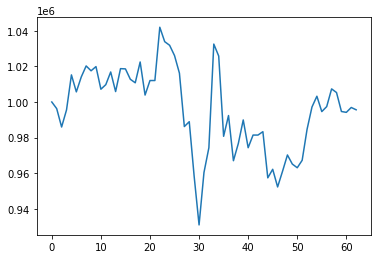

In [16]:
ensemble_account_value.account_value.plot()

In [17]:
ensemble_account_value = get_daily_return(ensemble_account_value)

Sharpe:  0.05410501616798546


In [18]:
ensemble_account_value['Date'] = test_ndq['Date']

In [19]:
ensemble_account_value.head()

,account_value,datadate,daily_return,Date
0,1.000000e+06,20190625,NaN,2019-06-24
1,9.962711e+05,20190626,-0.003729,2019-06-25
2,9.859527e+05,20190627,-0.010357,2019-06-26
3,9.955452e+05,20190628,0.009729,2019-06-27
4,1.015212e+06,20190701,0.019755,2019-06-28


In [20]:
ensemble_strat = backtest_strat(ensemble_account_value)

In [21]:
#ensemble_account_value.to_csv('results/df_account_value_ensemble_daily_return.csv',index=False)

Start date,2019-06-24
End date,2019-09-18
Total months,3
,Backtest
Annual return,-1.7%
Cumulative returns,-0.4%
Annual volatility,25.4%
Sharpe ratio,0.05
Calmar ratio,-0.16
Stability,0.19
Max drawdown,-10.7%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,10.65,2019-07-24,2019-08-05,NaT,NaN
1,1.82,2019-07-18,2019-07-19,2019-07-24,5
2,1.41,2019-07-03,2019-07-11,2019-07-18,12
3,1.40,2019-06-24,2019-06-26,2019-06-28,5
4,0.94,2019-06-28,2019-07-01,2019-07-03,4


C:\Users\Gabriele\Anaconda3\envs\clonenv\lib\site-packages\pyfolio\tears.py:926: UserWarning: Passed returns do not overlap with anyinteresting times.
  'interesting times.', UserWarning)


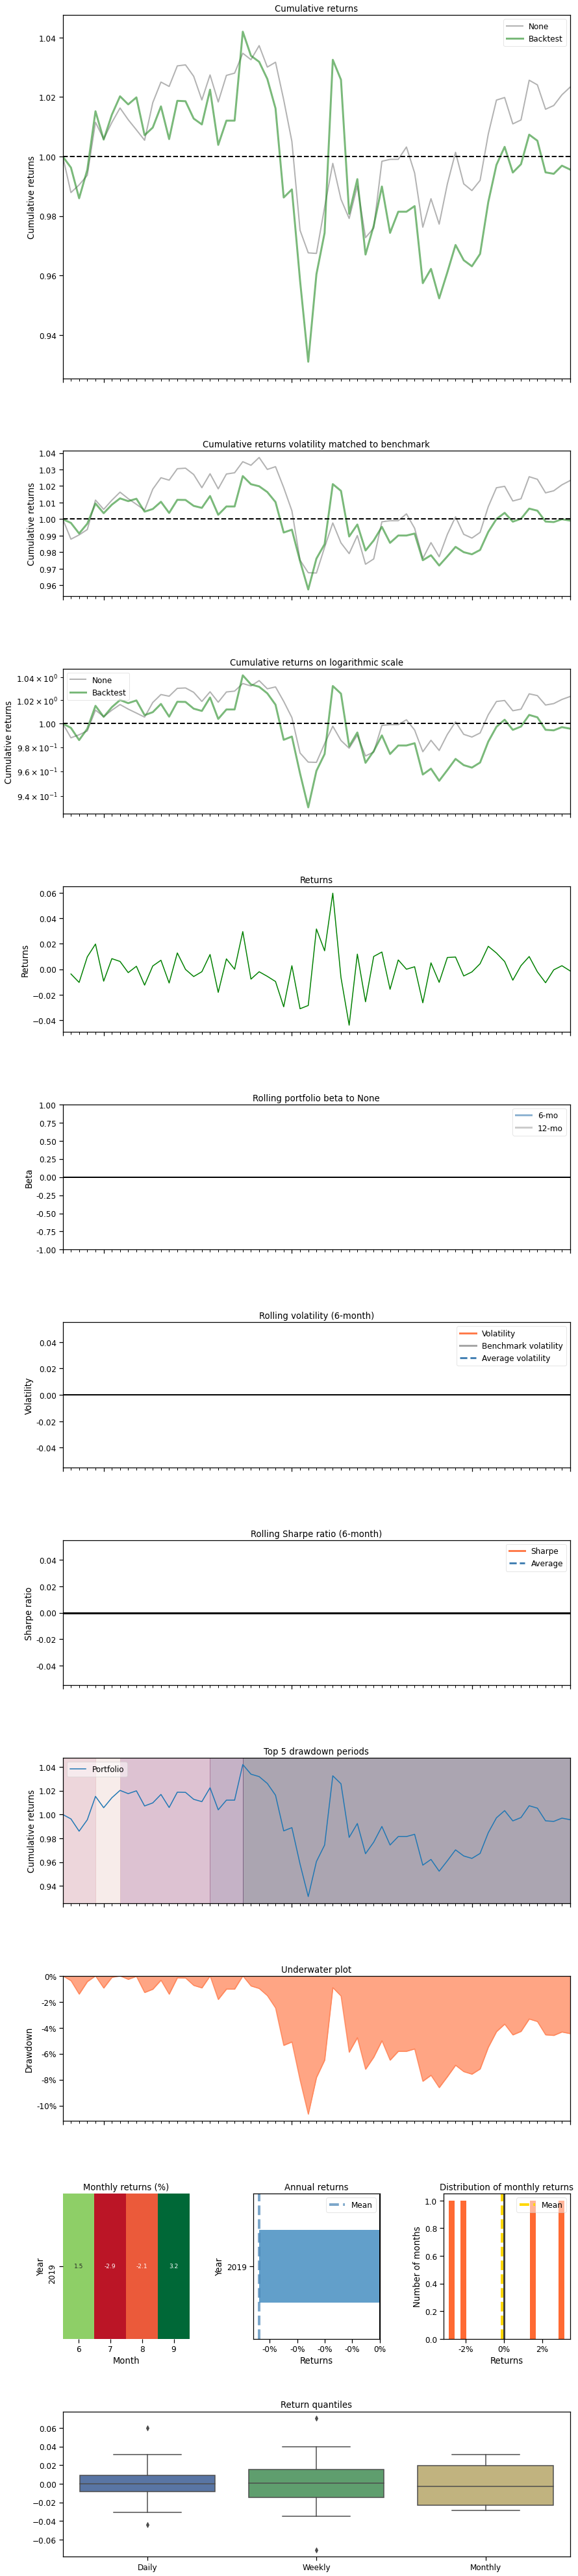

In [22]:
with pyfolio.plotting.plotting_context(font_scale=1.1):
    pyfolio.create_full_tear_sheet(returns = ensemble_strat,
                                   benchmark_rets=ndq_strat, set_context=False)